In [1]:
# 1. Baseline Model Train
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# 2. Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# 3. Evaluation Metrics
print("=== LOGISTIC REGRESSION RESULTS ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred_lr), 4))
print("Precision:", round(precision_score(y_test, y_pred_lr), 4))
print("Recall   :", round(recall_score(y_test, y_pred_lr), 4))
print("F1-Score :", round(f1_score(y_test, y_pred_lr), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_lr), 4))

print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

NameError: name 'LogisticRegression' is not defined

In [ ]:
# Train-Test Split (80% Train, 20% Test with Stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training Samples: {X_train.shape[0]}, Testing Samples: {X_test.shape[0]}")

Training Samples: 5634, Testing Samples: 1409


In [ ]:
# Train-Test Split (80% Train, 20% Test with Stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training Samples: {X_train.shape[0]}, Testing Samples: {X_test.shape[0]}")

Training Samples: 5634, Testing Samples: 1409


In [3]:
import pandas as pd
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# 1. Clean Data Load & Preprocess
df = pd.read_csv("../Data/telco_customer_churn_clean.csv")
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']
X = pd.get_dummies(X, drop_first=True)

# 2. Train-Test Split & Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 3. Model Training
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Save Directory & Serializing
os.makedirs("../Models", exist_ok=True)
joblib.dump(rf_model, "../Models/churn_random_forest_model.pkl")
joblib.dump(scaler, "../Models/scaler.pkl")

print("✅ Model and Scaler successfully trained and exported to Models/ folder!")

✅ Model and Scaler successfully trained and exported to Models/ folder!


In [4]:
import joblib
import os

# Create Models directory
os.makedirs("../Models", exist_ok=True)

# Export Model & Scaler
joblib.dump(rf_model, "../Models/churn_random_forest_model.pkl")
joblib.dump(scaler, "../Models/scaler.pkl")

print("✅ Model and Scaler exported successfully!")

✅ Model and Scaler exported successfully!


In [ ]:
# 1. Target Column Mapping (Yes -> 1, No -> 0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 2. Drop Identifier Column
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

# 3. One-Hot Encoding for Categorical Variables
X = pd.get_dummies(X, drop_first=True)

print("Features Shape after Encoding:", X.shape)
print("Target Value Counts:\n", y.value_counts(normalize=True))

Features Shape after Encoding: (7043, 30)
Target Value Counts:
 Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

# Clean Data Load
df = pd.read_csv("../Data/telco_customer_churn_clean.csv")
print("Data Shape:", df.shape)
df.head()

Data Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# 1. Load Data & Preprocess
df = pd.read_csv("../Data/telco_customer_churn_clean.csv")
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']
X = pd.get_dummies(X, drop_first=True)

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Predictions & Probabilities
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# 5. Output Metrics
print("=== RANDOM FOREST RESULTS ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall   :", round(recall_score(y_test, y_pred_rf), 4))
print("F1-Score :", round(f1_score(y_test, y_pred_rf), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_rf), 4))

print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

=== RANDOM FOREST RESULTS ===
Accuracy : 0.7864
Precision: 0.6237
Recall   : 0.492
F1-Score : 0.5501
ROC-AUC  : 0.8251

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.77      0.79      0.78      1409



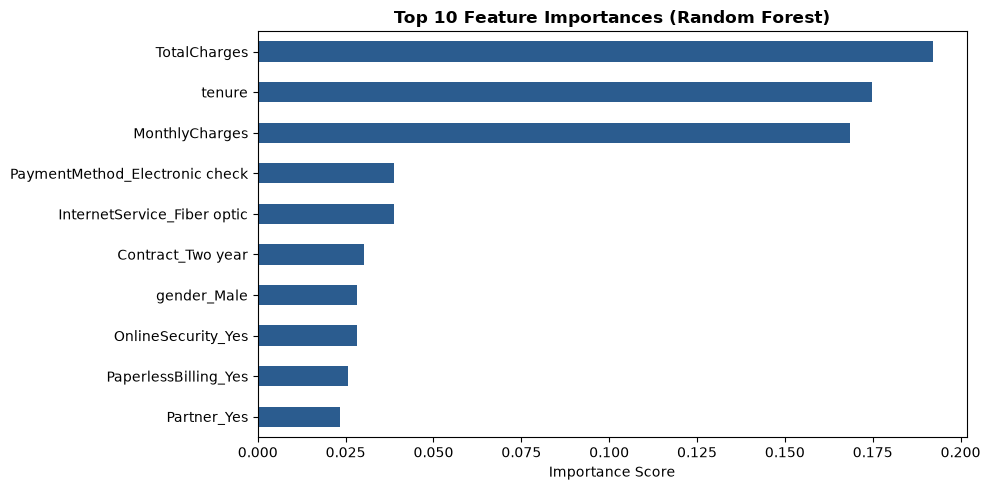

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 Feature Importance Extract Karein
importances = rf_model.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Chart Plot Karein
plt.figure(figsize=(10, 5))
feat_imp.head(10).plot(kind='barh', color='#2b5c8f')
plt.title("Top 10 Feature Importances (Random Forest)", fontsize=12, fontweight='bold')
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()

# Image Save Karein
plt.savefig("../visuals/feature_importance.png")
plt.show()

Best Hyperparameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Tuned RF F1-Score   : 0.58


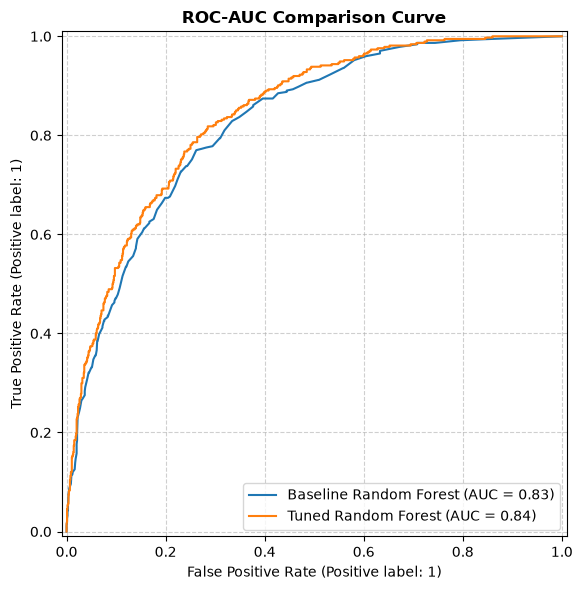

In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import RocCurveDisplay

# 1. Hyperparameter Tuning using GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf = best_rf.predict_proba(X_test)[:, 1]

print("Best Hyperparameters:", grid_search.best_params_)
print("Tuned RF F1-Score   :", round(f1_score(y_test, y_pred_best_rf), 4))

# 2. ROC-AUC Comparison Chart Plot Karein
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(rf_model, X_test, y_test, ax=plt.gca(), name='Baseline Random Forest')
RocCurveDisplay.from_estimator(best_rf, X_test, y_test, ax=plt.gca(), name='Tuned Random Forest')
plt.title("ROC-AUC Comparison Curve", fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Chart Save Karein
plt.savefig("../visuals/model_roc_comparison.png")
plt.show()